<details>
<summary> 모델별 특징과 장단점 비교</summary>

<!-- summary 아래 한칸 공백 두어야함 -->
## 고전적 얼굴 인식(얼굴 검출 및 식별) 모델의 특징과 장단점 비교
### 1. Haar Cascade (OpenCV 기본)

2001년에 제안된 고전적인 방식으로, 이미지의 밝기 차이(Haar-like features)를 이용해 얼굴을 찾습니다.

* **원리:** 눈 부위는 어둡고 콧등은 밝다는 식의 단순한 명암 패턴을 겹쳐보며 얼굴을 확인합니다.
* **장점:** 연산량이 매우 적어 **사양이 낮은 기기(라즈베리 파이, 구형 모바일)**에서도 실시간으로 돌아갈 만큼 빠릅니다.
* **단점:** * 옆모습이나 고개를 숙인 모습은 거의 찾지 못합니다.
* 조명 변화에 매우 취약하며, 얼굴이 아닌데 얼굴로 인식하는 **오탐(False Positive)**이 많습니다.

---

### 2. DNN (OpenCV Caffe 모델)

OpenCV 3.3 버전부터 포함된 딥러닝 기반 얼굴 검출기입니다. 보통 ResNet-10 구조를 사용합니다.

* **원리:** 인공 신경망(CNN)을 통해 이미지의 특징을 학습하여 얼굴을 찾습니다.
* **장점:** * Haar 방식보다 훨씬 **정확하며 안정적**입니다.
* 고개를 돌리거나 마스크를 써도 어느 정도 잡아냅니다.
* 다양한 이미지 크기에도 잘 대응합니다.


* **단점:** Haar 방식보다는 무겁기 때문에 아주 낮은 저사양 기기에서는 약간의 끊김이 있을 수 있습니다. (하지만 현대적인 PC나 스마트폰에서는 충분히 실시간 가능합니다.)

---

### 3. face_recognition (dlib 기반)

내부적으로 **HOG**나 **CNN(dlib)** 모델을 사용합니다.

* **원리:** 단순히 얼굴 위치만 찾는 게 아니라, 얼굴의 특징점(랜드마크) 68개를 찍고 이를 128차원의 숫자로 변환(Encoding)하여 **"누구인지"**까지 맞추는 데 특화되어 있습니다.
* **장점:** * **정확도가 매우 높습니다.** (CNN 모델 사용 시 LFW 데이터셋 기준 약 99.38%)
* 파이썬 코드가 매우 직관적이고 사용하기 쉽습니다.


* **단점:** * **가장 무겁습니다.** 특히 `model='cnn'` 옵션을 사용하면 GPU가 없을 경우 실시간 처리가 매우 힘듭니다.
* 설치 과정(dlib 빌드)이 까다롭습니다. 


</details>

| 구분 | Haar Cascade | DNN (Caffe) | face_recognition (dlib) |
| --- | --- | --- | --- |
| **정확도** | 낮음 | 높음 | **매우 높음** |
| **속도** | **매우 빠름** | 빠름 | 보통 ~ 느림 |
| **정면 외 인식** | 어려움 | 양호함 | **매우 우수함** |
| **주요 용도** | 초저사양 실시간 감지 | 범용 얼굴 검출 | **정밀 얼굴 인식 및 신원 확인** |
| **사용 난이도** | 쉬움 | 보통 | 매우 쉬움 (설치는 어려움) |

#### 💡 어떤 상황에 무엇을 쓸까요?

1. **라즈베리 파이 같은 초소형 기기**에서 단순히 사람 유무만 확인하고 싶다면? → **Haar**
2. **안정적으로 얼굴 위치**를 찾고 싶고, 옆모습도 잘 잡아야 한다면? → **DNN (Caffe)**
3. **누구인지 이름을 맞추거나 정밀한 얼굴 특징**이 필요하다면? → **face_recognition**

<details>
<summary> 더보기 : 핵심원리 및 기술적 특징 </summary>

<!-- summary 아래 한칸 공백 두어야함 -->

## Computer Vision: Face Detection & Recognition 프레임워크 비교 분석

### ** 1. Introduction: Face Processing Pipeline**

* **컴퓨터 비전의 얼굴 처리 단계:**
1. **Detection:** 이미지 내 얼굴 영역(Bounding Box) 식별
2. **Alignment:** 랜드마크 추출을 통한 기하학적 보정 (Affine Transformation)
3. **Encoding (Embedding):** 고차원 특징 벡터(128D) 추출
4. **Recognition:** 벡터 간 유클리드 거리 측정을 통한 분류(Classification)



### ** 2. Haar Cascade: Integral Image & Adaboost**

* **핵심 원리:** Haar-like feature를 활용한 슬라이딩 윈도우 방식.
* **기술적 특징:**
* **Integral Image:** 연산량 최소화를 위한 적분 이미지 기법 도입.
* **Cascade Classifier:** 배경을 빠르게 필터링하여 연산 효율 극대화.


* **한계점:** 고정된 수작업 특징(Hand-crafted feature) 사용으로 인한 낮은 강건성(Robustness). 조명 및 포즈 변화에 매우 취약함.

### ** 3. OpenCV DNN (Caffe): SSD with ResNet-10**

* **핵심 원리:** Single Shot MultiBox Detector(SSD) 아키텍처와 ResNet 기반 백본 사용.
* **기술적 특징:**
* 딥러닝 기반의 확률적 검출 (Confidence Score 산출).
* 다양한 스케일의 피처 맵을 활용한 멀티 스케일 검출 지원.


* **인사이트:** 전통적인 Haar 방식보다 mAP(mean Average Precision)가 월등히 높으며, CPU에서도 추론(Inference) 속도가 준수함.

### ** 4. Face_recognition (dlib-based): The Gold Standard**

* **핵심 원리:** **Metric Learning** 기반의 Deep Residual Network.
* **기술적 특징:**
* **Triplet Loss:** 같은 사람의 임베딩 거리는 가깝게, 타인은 멀게 학습.
* **Landmark Prediction:** 68개 포인트 회귀(Regression)를 통한 정밀 보정.


* **Model Options:**
* **HOG:** 가볍지만 오탐 발생 가능.
* **CNN (MMOD):** Max-Margin Object Detection 기술 적용, 고사양 연산 필요.

### ** 5. Comparative Analysis: Performance & Complexity**

| Metric | Haar Cascade | DNN (Caffe) | dlib (CNN) |
| --- | --- | --- | --- |
| **Approach** | Hand-crafted (Classic) | DL-based (SSD) | DL-based (ResNet) |
| **Robustness** | Low (Pose/Light sensitive) | High | **Very High** |
| **Speed (Inference)** | **Fastest** | Fast (Real-time) | Slow (Heavy) |
| **Hardware** | Low-end (Embedded) | Mid-range | **High-end (GPU req.)** |

### ** 6. Practical Implementation & Issues**

* **Environment Setup:** C++ 소스 컴파일 기반의 `dlib` 라이브러리 설치 시의 의존성(CMake, BLAS, LAPACK) 관리 이슈.
* **Data Integrity:** Dataset 경로 설정 및 이미지 무결성 검증의 중요성 (`OpenCV findDecoder` 에러 사례 분석).
* **Pickle Serialization:** 학습된 임베딩 데이터의 효율적인 직렬화 및 대용량 데이터베이스 관리 전략.
</details>

---

<details>
<summary> 최신 SOTA 모델 소개 </summary>

<!-- summary 아래 한칸 공백 두어야함 -->



## 1. InsightFace (ArcFace) - 연구 및 상용 끝판왕

현재 학계와 업계에서 가장 성능이 좋다고 평가받는 오픈소스 라이브러리입니다. `face_recognition` 라이브러리보다 더 최신 논문의 기법들을 구현해 놓았습니다.

* **핵심 알고리즘:** **ArcFace (Additive Angular Margin Loss)**
* **특징:** 얼굴 특징 벡터를 추출할 때 거리뿐만 아니라 '각도(Angle)' 개념을 도입하여, 클래스 간 분별력을 극대화했습니다.
* **실무 활용:** 수백만 명 이상의 대규모 얼굴 데이터베이스에서 중복을 찾거나 신원을 확인할 때 독보적인 정확도를 보입니다.
* **지원:** PyTorch와 MXNet 기반으로 구현되어 있으며, GPU 가속 성능이 매우 뛰어납니다.

---

## 2. MediaPipe (by Google) - 모바일 및 실시간 최적화

구글에서 개발한 프레임워크로, 스마트폰 앱이나 웹 브라우저 환경에서 실시간 얼굴 인식을 구현할 때 사실상의 표준(Standard)입니다.

* **핵심 모델:** **BlazeFace**
* **특징:** 모바일 GPU에 최적화된 매우 가벼운 모델입니다. 얼굴뿐만 아니라 손가락, 포즈, 홍채 추적까지 통합적으로 제공합니다.
* **장점:** 설치가 매우 쉽고(pip install mediapipe), 별도의 복잡한 빌드 과정 없이 CPU에서도 압도적인 속도(30 FPS 이상)를 보여줍니다.
* **실무 활용:** AR 필터(스노우 같은 앱), 웹캠 기반 졸음 감지, 비대면 본인 인증 인터페이스 등에 주로 쓰입니다.

---

## 3. MTCNN (Multi-task Cascaded Convolutional Networks)

딥러닝 기반 얼굴 검출기 중 가장 고전적이면서도 신뢰받는 모델입니다. 세 개의 네트워크(P-Net, R-Net, O-Net)가 단계적으로 얼굴을 정교하게 찾아냅니다.

* **특징:** 얼굴 검출(Detection)과 동시에 랜드마크(눈, 코, 입꼬리 5개 지점) 추출 및 정렬(Alignment)을 한 번에 수행합니다.
* **장점:** 이미지 안에 얼굴이 작게 있거나, 여러 명이 겹쳐 있는 상황에서도 매우 강건(Robust)하게 작동합니다.
* **실무 활용:** 다른 인식 모델(ArcFace 등)에 얼굴을 입력하기 전, 얼굴을 바르게 펴주는 **전처리(Preprocessing)** 단계에서 필수적으로 사용됩니다.

---

### **추천하는 실무 파이프라인**

실제로 현업에서 프로젝트를 구성할 때는 하나만 쓰지 않고 다음과 같이 조합합니다.

1. **검출(Detection):** **MTCNN** 또는 **MediaPipe**로 얼굴 위치와 랜드마크를 빠르게 찾음.
2. **보정(Alignment):** 찾아낸 랜드마크를 기준으로 얼굴을 수평으로 맞춤 (인식률 향상에 필수).
3. **인식(Recognition):** 보정된 이미지를 **InsightFace(ArcFace)** 모델에 넣어 512차원 벡터로 변환 후 비교.

</details>

대학원 수준의 실무 프로젝트나 대규모 상용 서비스에서는 앞서 언급한 세 가지 방식 외에도 **딥러닝 프레임워크(PyTorch, TensorFlow)에 최적화된 최신 SOTA(State-Of-The-Art) 모델**들을 주로 사용합니다.

성능, 속도, 그리고 모바일 이식성 측면에서 가장 많이 언급되는 3가지를 소개해 드립니다.

| 구분 | MediaPipe | MTCNN | InsightFace (ArcFace) |
| --- | --- | --- | --- |
| **주 목적** | 실시간 트래킹 (Edge) | 얼굴 검출 및 정렬 (Preprocessing) | 고정밀 신원 식별 (Recognition) |
| **강점** | 압도적인 속도, 접근성 | 정교한 박스 및 랜드마크 | SOTA급 정확도, 대규모 데이터 |
| **런타임** | CPU/GPU/NPU(모바일) | CPU/GPU | GPU 권장 |
| **프레임워크** | C++/Python/JS | TensorFlow/PyTorch | PyTorch/MXNet |

---

<details>
<summary> 이론적 배경</summary>

<!-- summary 아래 한칸 공백 두어야함 -->
## 2. 이론적 배경 (Theoretical Background)

### 2.1 Deep Face Recognition Pipeline

현대적인 얼굴 인식 시스템은 단일 모델이 아닌, 여러 최적화된 서브 태스크들의 연속(Pipeline)으로 구성됩니다.

1. **Face Detection (검출):** 이미지 내에서 얼굴 영역의 Bounding Box를 식별합니다.
* *SOTA 모델:* **RetinaFace**. FPN(Feature Pyramid Network)과 SSH(Single Stage Head) 구조를 사용하여 다양한 스케일의 얼굴과 미세한 랜드마크를 동시에 검출합니다.


2. **Face Alignment (정렬):** 검출된 얼굴의 주요 랜드마크(눈, 코, 입 등)를 기준으로 회전, 크기, 전단(Shear) 변환을 수행하여 얼굴을 정면으로 보정합니다.
* *중요성:* 정렬 과정을 거치지 않으면 특징 추출 시 포즈 변화에 따른 노이즈가 크게 발생하여 인식률이 급격히 저하됩니다.


3. **Feature Extraction (임베딩):** 정렬된 얼굴 이미지를 신경망에 통과시켜 고유한 특징 벡터(주로 512차원)로 변환합니다.
* *구조:* ResNet 기반의 백본 네트워크를 주로 사용하며, 마지막 Layer에서 특징 추출을 수행합니다.


4. **Face Matching (매칭):** 추출된 두 벡터 사이의 유사도를 측정합니다.
* **Euclidean Distance**() 또는 **Cosine Similarity**를 주로 사용합니다.



---

### 2.2 고전적 Metric Learning의 한계

얼굴 인식은 클래스 수가 수만 개 이상이고 학습 데이터에 없는 인물을 식별해야 하는 **Open-set Recognition** 문제입니다.

* **Triplet Loss (FaceNet, 2015):** * 수식: 
* *문제점:* 학습 데이터셋이 커질수록 가능한 조합()이 기하급수적으로 증가하며, 'Semi-hard negative'를 찾는 과정(Mining)이 매우 까다롭고 연산 비용이 높습니다.



---

### 2.3 ArcFace: Additive Angular Margin Loss의 기하학적 해석

ArcFace는 유클리드 공간의 거리가 아닌 **각도 공간(Angular Space)**에서 클래스 간의 변별력을 확보합니다.

#### **Step 1: Weight and Feature Normalization**

기존 Softmax의 로짓()에서 편향()을 제거하고  정규화를 적용하여 특징 벡터를 초구체(Hypersphere) 표면에 매핑합니다.


#### **Step 2: Angular Margin Penalty ()**

정답 클래스()와의 각도 에 마진 을 직접 더하여 패널티를 줍니다.



이는 구 표면에서 정답 클래스의 중심과 샘플 사이의 **호(Arc)**의 길이를 조절하는 것과 같습니다.

#### **Step 3: Discriminative Power**

* **Intra-class Compactness:** 같은 클래스 샘플들이 매우 좁은 각도 내로 밀집됩니다.
* **Inter-class Discrepancy:** 다른 클래스 중심들 사이의 각도 경계가 명확해져 오인식률을 획기적으로 낮춥니다.

---

### 2.4 Evaluation Metrics: 코사인 유사도 vs 유클리드 거리

ArcFace 모델은 학습 시 각도를 최적화했으므로, 추론 시에도 각도 기반의 **Cosine Similarity**를 사용하는 것이 수치적으로 더 일관성 있는 결과를 제공합니다.

* **Cosine Similarity Range:**  (보통 얼굴 인식 임계값은 0.4~0.5 설정)
* **특징:** 벡터의 크기보다는 방향성에 집중하므로 조명 변화 등에 더 강건합니다.

---

</details>

1.1 얼굴 인식 모델 비교
- Haar Cascade: 명암 차이 기반, 매우 빠름, 정확도 낮음.
- OpenCV DNN: SSD 기반, 안정적 검출.
- face_recognition: dlib 기반, 사용성 우수, 설치 복잡.
- InsightFace: ArcFace(SOTA) 적용, 최고 수준의 정확도.

1.2 Metric Learning의 진화: Loss Functions
1. Contrastive Loss: Pair간 유클리드 거리 직접 제어.
2. Triplet Loss: Anchor-Positive-Negative 간 상대적 거리 학습.
3. ArcFace (Additive Angular Margin Loss):
   - 특징 벡터를 초구체(Hyper-sphere)에 매핑.
   - 각도 공간에서 마진(m)을 추가하여 변별력 극대화: cos(theta + m)

In [ ]:
# =================================================================
# Deep Learning 기반 얼굴 인식 기술의 이해와 실무 적용
# 주제: 고전적 기법부터 SOTA(ArcFace) 모델까지의 Loss Function 및 Pipeline 분석
# =================================================================

# 환경 구축 및 라이브러리 설치
# !pip install insightface onnxruntime-gpu

import cv2
import numpy as np
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

# =================================================================
# 2. InsightFace 모델 초기화 및 설정
# =================================================================

# buffalo_l: Detection(RetinaFace) + Recognition(ArcFace) 통합 모델
# providers: GPU 가속을 위해 CUDAExecutionProvider 우선 순위 설정
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])

# ctx_id=0: 첫 번째 GPU 사용
# det_size: 검출 해상도 설정 (640x640은 속도와 정확도의 밸런스 지점)
app.prepare(ctx_id=0, det_size=(640, 640))

# =================================================================
# 3. 핵심 함수 구현: 특징 추출 및 비교
# =================================================================

def get_embedding(img_path):
    """
    이미지에서 얼굴을 검출하고 512차원 특징 벡터(Embedding)를 추출합니다.
    """
    img = cv2.imread(img_path)
    if img is None:
        return None
    
    # BGR to RGB 변환 (InsightFace는 RGB 입력을 기대함)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 얼굴 검출 및 특징 추출 실행
    faces = app.get(img_rgb)
    
    if not faces:
        print(f"No face detected in {img_path}")
        return None
    
    # faces[0].embedding: ArcFace를 통해 얻은 512차원 Identity 벡터
    return faces[0].embedding

def find_target_in_group(group_img_path, target_vec, threshold=0.45):
    """
    단체 사진 내에서 타겟 벡터와 유사한 얼굴을 찾아 표시합니다.
    """
    group_img = cv2.imread(group_img_path)
    if group_img is None: return
    
    group_rgb = cv2.cvtColor(group_img, cv2.COLOR_BGR2RGB)
    faces = app.get(group_rgb)

    for face in faces:
        # [수학적 핵심]: Cosine Similarity 계산
        # dot(A, B) / (norm(A) * norm(B))
        feat = face.embedding
        sim = np.dot(target_vec, feat) / (np.linalg.norm(target_vec) * np.linalg.norm(feat))
        
        bbox = face.bbox.astype(int)
        
        # Threshold 비교 (ArcFace 기준 0.4~0.5가 적정선)
        if sim > threshold:
            # 일치하는 인물: 초록색 사각형
            color = (0, 255, 0)
            label = f"MATCH: {sim:.2f}"
            width = 3
        else:
            # 타인: 빨간색 사각형
            color = (255, 0, 0)
            label = f"Unknown: {sim:.2f}"
            width = 1
            
        cv2.rectangle(group_rgb, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, width)
        cv2.putText(group_rgb, label, (bbox[0], bbox[1]-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # 시각화 (Colab/Jupyter 환경)
    plt.figure(figsize=(12, 8))
    plt.imshow(group_rgb)
    plt.title(f"Face Matching Result (Threshold: {threshold})")
    plt.axis('off')
    plt.show()

# =================================================================
# 4. 실행 (Execution)
# =================================================================

# 1) 타겟 인물의 특징 추출 (예: 사진 속에서 찾고 싶은 사람의 단독 사진)
# target_vector = get_embedding('path_to_target.jpg')

# 2) 단체 사진에서 탐색 실행
# if target_vector is not None:
#     find_target_in_group('path_to_group_photo.jpg', target_vector)

"""
## 5. 결론 및 학술적 요약 (Conclusion)
- 고전적인 Triplet Loss 대비 ArcFace는 각도 공간에서의 마진을 통해 높은 변별력을 가짐.
- 실무 파이프라인 구성 시 RetinaFace(Detection) + ArcFace(Embedding) 조합이 가장 강력함.
- 향후 연구 과제: 대규모 데이터셋에서의 검색 속도 최적화(Vector DB 활용 등).
"""

# 실제 colab 실행 코드

In [ ]:
### InsightFace

### 1. Installation
!pip install opencv-python onnxruntime-gpu
!pip install insightface
!pip install matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 15.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 127.7 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071486 sha256=49096da0e8d05345f47a5e177139622ad4de8d71e46dad95083345d8ab5f36e9
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [4]:
# from google.colab import drive
import cv2
import numpy as np
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

# # 구글 드라이브 연결
# drive.mount('/content/drive')

# 여기에 사진이 저장된 실제 경로를 입력하세요.
# 예: '/content/drive/MyDrive/project/target.jpg'
target_path = '5.jpg'
group_path = 'soccer_01.jpg'

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

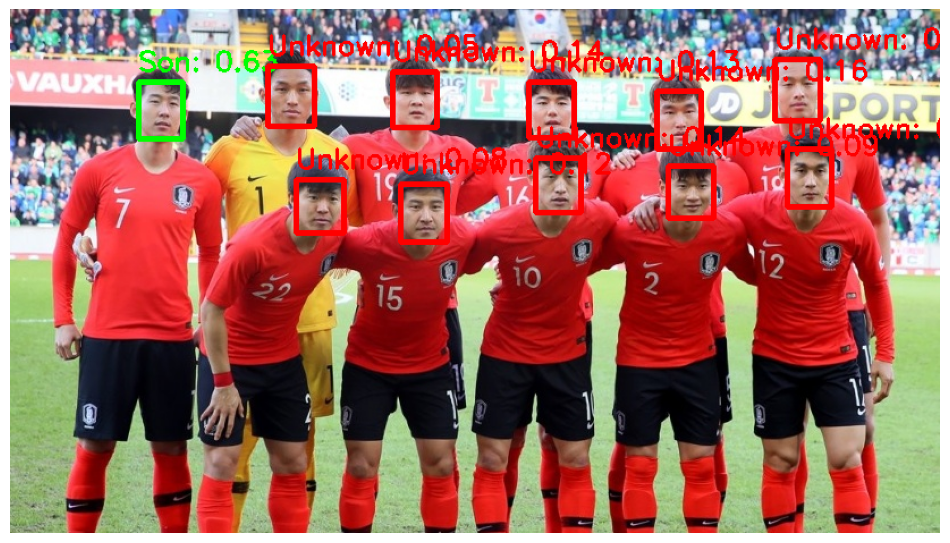

In [ ]:
# 1. 모델 초기화 (GPU 사용 설정: providers=['CUDAExecutionProvider'])
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

def get_embedding(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"파일을 찾을 수 없습니다: {img_path}")
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = app.get(img_rgb)
    if len(faces) == 0:
        print(f"얼굴을 검출하지 못했습니다: {img_path}")
        return None
    # 가장 큰 얼굴의 특징 벡터 반환
    return faces[0].embedding

# 2. 특정 인물(Target) 특징 추출
target_vec = get_embedding(target_path)

# 3. 단체 사진 분석
if target_vec is not None:
    group_img = cv2.imread(group_path)
    group_rgb = cv2.cvtColor(group_img, cv2.COLOR_BGR2RGB)
    faces = app.get(group_rgb)

    for face in faces:
        # 코사인 유사도 계산
        feat = face.embedding
        sim = np.dot(target_vec, feat) / (np.linalg.norm(target_vec) * np.linalg.norm(feat))

        # 유사도 0.45 기준으로 바운딩 박스 표시
        bbox = face.bbox.astype(int)
        if sim > 0.45:
            color = (0, 255, 0) # 초록색: 일치
            label = f"Son: {sim:.2f}"
        else:
            color = (255, 0, 0) # 빨간색: 불일치
            label = f"Unknown: {sim:.2f}"

        cv2.rectangle(group_rgb, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 3)
        cv2.putText(group_rgb, label, (bbox[0], bbox[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # 4. 코랩 결과 출력 (cv2.imshow 대신 matplotlib 사용)
    plt.figure(figsize=(12, 8))
    plt.imshow(group_rgb)
    plt.axis('off')
    plt.show()